In [1]:
from insightface.app import FaceAnalysis
from detector import GenderAnalysis

2026-05-14 15:19:09.646445292 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [2]:
app = FaceAnalysis(allowed_modules=['detection', 'recognition', 'genderage'])
app.prepare(ctx_id=0, det_size=(320,320))

/home/emi/anaconda3/envs/insight/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/emi/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/emi/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/emi/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/emi/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/emi/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)


In [3]:
det = GenderAnalysis(app, gamma=3, use_bilateral=False)

In [4]:
embedding = 'lfw_genderage_insightface.pkl'
embed_dir = 'lfw'

In [5]:
from pathlib import Path
path = Path(embedding)

if not path.exists():
    det.embed_all(embed_dir, embedding)

In [6]:
data = det.get_all_embeddings(embedding)

In [7]:
# result = det.evaluate_gender_accuracy()
result = det.evaluate_lfw_gender_accuracy(embedding)

/home/emi/anaconda3/envs/insight/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Guardada: out/Alexandra Stevenson.jpg
Guardada: out/Keith Foulke.jpg
Guardada: out/Corliss Williamson.jpg
Guardada: out/Christine Arron.jpg
Guardada: out/Cheryl James.jpg
Guardada: out/Marsha Sharp.jpg
Guardada: out/Jacqueline Edwards.jpg
Guardada: out/Teresa Worbis.jpg
Guardada: out/Mike Bryan.jpg
Guardada: out/Izzat Ibrahim.jpg
Guardada: out/Silvia Farina.jpg
Guardada: out/Silvia Farina.jpg
Guardada: out/Jelena Dokic.jpg
Guardada: out/Jelena Dokic.jpg
Guardada: out/Jelena Dokic.jpg
Guardada: out/Jelena Dokic.jpg
Guardada: out/Jelena Dokic.jpg
Guardada: out/Jelena Dokic.jpg
Guardada: out/Patti Smith.jpg
Guardada: out/Petria Thomas.jpg
Guardada: out/Petria Thomas.jpg
Guardada: out/Petria Thomas.jpg
Guardada: out/Tommy Shane.jpg
Guardada: out/Rupert Grint.jpg
Guardada: out/Adrian Fernandez.jpg
Guardada: out/Lorraine Fenton.jpg
Guardada: out/Elton John.jpg
Guardada: out/Elton John.jpg
Guardada: out/Elton John.jpg
Guardada: out/Elton John.jpg


In [10]:
if result:
    n_exitos, n_errores, pce_exitos, pce_errores, err_mujeres, err_hombres, pcte_dif = result
    print(f'de {n_exitos + n_errores} imagenes analizadas, estos son los resultados:')
    print(f'exitos: {n_exitos}, errores: {n_errores}, exitos {pce_exitos:.2f}%, errores {pce_errores:.2f}%')
    print(f'cantidad de mujeres mal analizadas: {err_mujeres}')
    print(f'cantidad de hombres mal analizados: {err_hombres}')
    print(f'porcentage de diferencia frente al total de errores: {pcte_dif:.2f}')

de 9777 imagenes analizadas, estos son los resultados:
exitos: 9236, errores: 541, exitos 94.47%, errores 5.53%
cantidad de mujeres mal analizadas: 357
cantidad de hombres mal analizados: 184
porcentage de diferencia frente al total de errores: 31.98


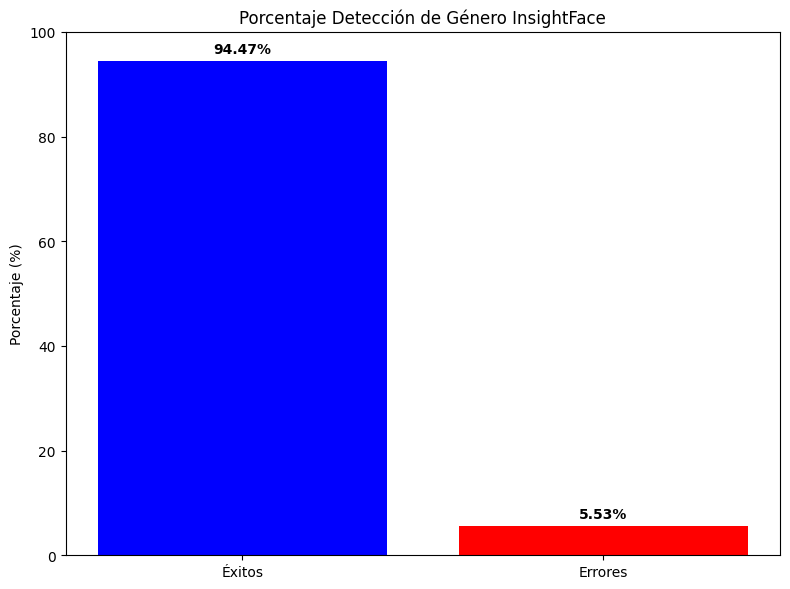

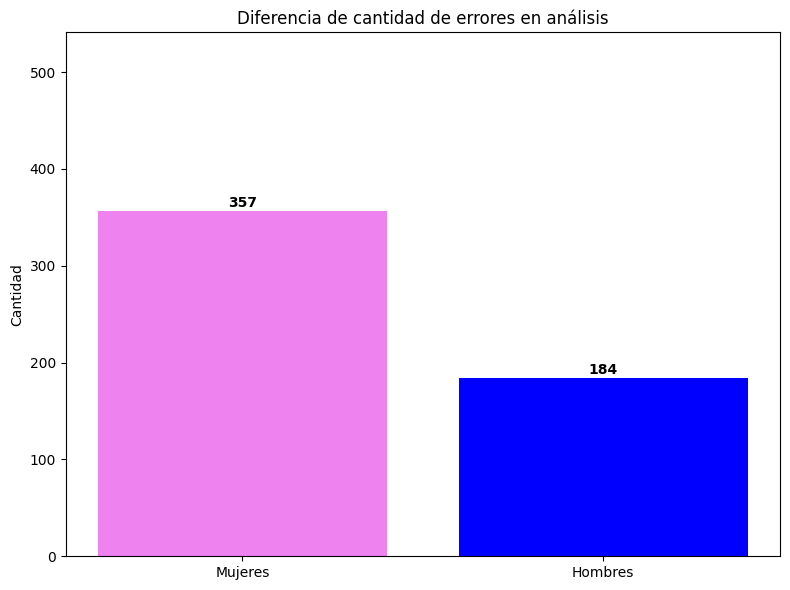

In [9]:
det.plot_gender_accuracy(result)
det.plot_gender_diff(result)